In [ ]:
# Import necessary libraries and dowwnload required info

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import yfinance as yf

tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "JPM", "UNH", "XOM", "PG",
    "HD", "V", "MA", "BAC", "KO",
    "PEP", "AVGO", "COST", "WMT", "DIS"
]

# auto_adjust=True: prices are adjusted for corporate actions (splits/dividends). 
# This helps avoid “artificial” jumps in historical prices.

# group_by="ticker": the returned dataframe is structured so raw[ticker] gives the 
# OHLCV columns for that ticker.

raw = yf.download(
    tickers,
    start="2018-01-01",
    end="2025-12-31",
    auto_adjust=True,
    group_by="ticker"
)

[*********************100%***********************]  20 of 20 completed


## Convert raw yfinance output into a panel dataframe

`yfinance.download(..., group_by="ticker")` returns a dataframe where each ticker has its own OHLCV sub-table.
For alpha research it’s much easier to work with a single “panel” (long-form) dataframe.

In the loop below, for each `ticker` we:
1. Take the OHLCV rows for that ticker (`raw[ticker]`)
2. Normalize column names (lowercase, spaces -> underscores)
3. Add:
   - `ticker`: the stock identifier
   - `date`: the row timestamp from the index
4. Concatenate all tickers into one dataframe (`df`)

Finally we sort by `["ticker", "date"]` so that time-series operations like `shift`, `pct_change`, and `rolling`
are applied in the correct chronological order per ticker.

In [ ]:
frames = []

for ticker in tickers:
    temp = raw[ticker].copy()
    temp.columns = [c.lower().replace(" ", "_") for c in temp.columns]
    temp["ticker"] = ticker
    temp["date"] = temp.index
    frames.append(temp)

df = pd.concat(frames)
df = df.reset_index(drop=True)
df = df.sort_values(["ticker", "date"])
df.to_csv("/Users/JinhanZhang/Documents/AlphaForge-AI/data/prices_panel.csv", index=False)


<bound method NDFrame.head of              open        high         low       close     volume ticker  \
0       39.776178   40.276419   39.565794   40.267067  102223600   AAPL   
1       40.330187   40.802379   40.196947   40.260059  118071600   AAPL   
2       40.332529   40.549925   40.225002   40.447071   89738400   AAPL   
3       40.542909   40.994059   40.451743   40.907570   94640000   AAPL   
4       40.755627   41.050160   40.657445   40.755627   82271200   AAPL   
...           ...         ...         ...         ...        ...    ...   
18085  116.892184  118.431405  116.744180  117.829529   12567600    XOM   
18086  117.740722  118.451134  117.533520  117.632187    6137400    XOM   
18087  117.306588  117.957801  116.951382  117.523659    8066100    XOM   
18088  118.549807  119.684493  117.809796  118.924744   14782500    XOM   
18089  119.487152  120.177834  119.023410  119.378616   11150500    XOM   

            date  
0     2018-01-02  
1     2018-01-03  
2     2018-0

## Create the prediction target and five simple alpha features

We evaluate signals by measuring how well an alpha at time `t` predicts the **forward return** from `t` to `t+1`.

### Target: next-day close-to-close return
For each ticker, we compute:

- `future_return_1d(t) = close(t+1) / close(t) - 1`

So a model that works would produce alpha values that are positively correlated with `future_return_1d`.

### Alpha definitions
For each ticker, we also compute these features at time `t`:

1. **`momentum_5d` (5-day momentum)**
   - `momentum_5d(t) = close(t) / close(t-5) - 1`
   - What it means: positive values indicate the price has risen over the past ~5 trading days.
   - Intuition: if momentum exists, strong recent winners tend to continue (and vice versa).

2. **`mean_reversion_1d` (1-day mean reversion)**
   - `mean_reversion_1d(t) = - (close(t) / close(t-1) - 1)`
   - What it means: it is the negative of yesterday’s return.
   - Intuition: after a short-term drop, the alpha becomes positive (suggesting a bounce next day).

3. **`volume_spike` (volume anomaly vs 20-day average)**
   - `volume_spike(t) = volume(t) / MA(volume, 20)(t) - 1`
   - What it means: positive values indicate volume is above its recent average.
   - Intuition: unusual activity may precede price moves, but direction can vary by regime.

4. **`volatility_breakout` (intraday range / close)**
   - `volatility_breakout(t) = (high(t) - low(t)) / close(t)`
   - What it means: a simple measure of today’s intraday movement relative to price.
   - Intuition: large ranges can be associated with breakouts or regime shifts.

5. **`overnight_gap` (open relative to prior close)**
   - `overnight_gap(t) = open(t) / close(t-1) - 1`
   - What it means: how much price “gapped” between the prior close and today’s open.
   - Intuition: gaps can predict next-day behavior, but the relationship may depend on news impact.

> Note: all alphas are computed per ticker using rolling windows and percentage changes.
> The goal is not to “trade” yet, but to test whether each feature is correlated with forward returns.

In [6]:
g = df.groupby("ticker", group_keys=False)

df["future_return_1d"] = g["close"].shift(-1) / df["close"] - 1

df["momentum_5d"] = g["close"].pct_change(5)
df["mean_reversion_1d"] = -g["close"].pct_change(1)
df["volume_spike"] = df["volume"] / g["volume"].transform(lambda x: x.rolling(20).mean()) - 1
df["volatility_breakout"] = (df["high"] - df["low"]) / df["close"]
df["overnight_gap"] = df["open"] / g["close"].shift(1) - 1
df.to_csv("/Users/JinhanZhang/Documents/AlphaForge-AI/data/prices_with_alpha.csv", index=False)


## Compute daily Information Coefficient (IC)

The Information Coefficient (IC) measures how strongly an alpha correlates with realized future returns **across tickers on the same date**.

For each `date`:
1. Collect the alpha values (`alpha_col`) for all tickers on that date
2. Collect the realized forward returns (`future_return_1d`) for those same tickers
3. Drop missing values and require at least a minimum number of tickers
4. Compute:
   - **Pearson IC (`ic`)**: linear correlation
   - **Spearman Rank IC (`rank_ic`)**: correlation between ranks (monotonic relationship)

If an alpha is useful, then tickers with higher alpha scores on date `t` should tend to have higher realized `future_return_1d` on date `t`.

In [8]:
def daily_ic(data, alpha_col, target_col="future_return_1d"):
    results = []

    for date, group in data.groupby("date"):
        temp = group[[alpha_col, target_col]].dropna()

        if len(temp) < 5:
            continue

        pearson_ic = temp[alpha_col].corr(temp[target_col])
        rank_ic = spearmanr(temp[alpha_col], temp[target_col]).correlation

        results.append({
            "date": date,
            "alpha": alpha_col,
            "ic": pearson_ic,
            "rank_ic": rank_ic,
            "n": len(temp)
        })

    return pd.DataFrame(results)

## Evaluate and summarize all alphas with IC statistics

For each alpha feature we compute a daily series of:
- `ic` (Pearson IC)
- `rank_ic` (Spearman Rank IC)

Then we summarize performance across time:

- `mean_ic`: average daily Pearson IC
- `ic_std`: volatility (standard deviation) of daily IC
- `icir = mean_ic / ic_std`: a stability-adjusted IC score
- `mean_rank_ic`: average daily Rank IC
- `rank_ic_std`, `rank_icir`: same but for Rank IC

Finally, we sort by `mean_rank_ic` to find signals with the strongest average monotonic relationship
between alpha and next-day returns.

In [10]:
alpha_cols = [
    "momentum_5d",
    "mean_reversion_1d",
    "volume_spike",
    "volatility_breakout",
    "overnight_gap"
]

all_ic = pd.concat(
    [daily_ic(df, alpha) for alpha in alpha_cols],
    ignore_index=True
)
all_ic.to_csv("/Users/JinhanZhang/Documents/AlphaForge-AI/data/alpha_with_ic_by_date.csv", index=False)


summary = (
    all_ic
    .groupby("alpha")
    .agg(
        mean_ic=("ic", "mean"),
        mean_rank_ic=("rank_ic", "mean"),
        ic_std=("ic", "std"),
        rank_ic_std=("rank_ic", "std"),
        observations=("ic", "count")
    )
)

summary["icir"] = summary["mean_ic"] / summary["ic_std"]
summary["rank_icir"] = summary["mean_rank_ic"] / summary["rank_ic_std"]
summary = summary.reset_index()

summary.sort_values("mean_rank_ic", ascending=False)
summary.to_csv("/Users/JinhanZhang/Documents/AlphaForge-AI/data/performance_summary.csv", index=False)

## Simple cross-sectional long/short backtest (top/bottom quantiles)

IC tells us whether an alpha is *correlated* with next-day returns, but it does not directly answer:
“**If I trade this signal, do I make money?**”

Here we run a very simple daily long/short simulation:

For each trading date `t`:
1. Take all tickers with non-missing values for:
   - the alpha score `alpha_col(t)`
   - the realized next-day return `future_return_1d(t)`
2. Rank tickers by the alpha score and split into quantiles.
3. **Go long** the top `q` fraction by alpha (e.g., top 20%).
4. **Go short** the bottom `q` fraction by alpha (e.g., bottom 20%).
5. Compute the portfolio’s next-day return as:


### Key terms
- **Cross-sectional**: we compare stocks *to each other on the same day* (not one stock over time).
- **Quantile**: a threshold based on the alpha distribution each day (e.g., 0.2 means 20% tails).
- **Long-short return**: the difference between average returns of the long and short baskets.
- **Dollar-neutral intuition**: long and short legs are equally weighted (by simple averaging here), so market direction is partly hedged—but not perfectly.

> Important: This is a research-grade “toy” backtest: it ignores transaction costs, borrow fees, slippage,
> corporate actions edge cases, and realistic portfolio constraints. It’s still a great first sanity check.

In [11]:
def long_short_backtest(data, alpha_col, target_col="future_return_1d", quantile=0.2):
    rows = []

    for date, group in data.groupby("date"):
        temp = group[[alpha_col, target_col]].dropna()

        if len(temp) < 10:
            continue

        low_cutoff = temp[alpha_col].quantile(quantile)
        high_cutoff = temp[alpha_col].quantile(1 - quantile)

        long_return = temp.loc[temp[alpha_col] >= high_cutoff, target_col].mean()
        short_return = temp.loc[temp[alpha_col] <= low_cutoff, target_col].mean()

        rows.append({
            "date": date,
            "alpha": alpha_col,
            "long_return": long_return,
            "short_return": short_return,
            "long_short_return": long_return - short_return
        })

    return pd.DataFrame(rows)

## Run the backtest for each alpha and compute performance statistics

We run the long/short procedure for each alpha column in `alpha_cols`, producing a daily time series of:
- `long_return`: average next-day return of tickers in the top quantile
- `short_return`: average next-day return of tickers in the bottom quantile
- `long_short_return = long_return - short_return`

Then we summarize each alpha’s long/short return stream:

- `avg_daily_return`: average of daily long/short returns
- `daily_vol`: standard deviation of daily long/short returns (a volatility estimate)
- `annualized_return ≈ avg_daily_return × 252`
- `annualized_vol ≈ daily_vol × sqrt(252)`
- `sharpe = annualized_return / annualized_vol`

### What these metrics mean
- **Annualization**: we scale daily statistics to an approximate “per-year” number assuming ~252 trading days.
- **Sharpe ratio**: risk-adjusted return (higher is better), but can be misleading if:
  - returns are non-normal / have fat tails
  - volatility is unstable over time
  - transaction costs would materially reduce returns

> With only 20 tickers, quantile portfolios can be small (e.g., 20% tails = ~4 names per side),
> so results can be noisy and sensitive to outliers.

In [14]:
bt_results = pd.concat(
    [long_short_backtest(df, alpha) for alpha in alpha_cols],
    ignore_index=True
)

bt_summary = (
    bt_results
    .groupby("alpha")
    .agg(
        avg_daily_return=("long_short_return", "mean"),
        daily_vol=("long_short_return", "std"),
        days=("long_short_return", "count")
    )
)

bt_summary["annualized_return"] = bt_summary["avg_daily_return"] * 252
bt_summary["annualized_vol"] = bt_summary["daily_vol"] * np.sqrt(252)
bt_summary["sharpe"] = bt_summary["annualized_return"] / bt_summary["annualized_vol"]

bt_summary = bt_summary.reset_index()  # alpha becomes a column

bt_summary.sort_values("sharpe", ascending=False)

bt_summary.to_csv("/Users/JinhanZhang/Documents/AlphaForge-AI/data/backtest_summary.csv", index=False)

## Plot cumulative long/short returns over time

To visualize the backtest, we convert the daily long/short returns into a cumulative return curve:

\[
\text{cum\_return}(t) = \prod_{s \le t} (1 + r_{LS}(s)) - 1
\]

This compounding shows:
- whether performance is persistent or concentrated in a short window
- drawdowns (peak-to-trough declines)
- regime dependence (periods where the signal works vs. fails)

Notes:
- We fill missing daily returns with 0 before compounding, which keeps the series continuous.
  Depending on why data is missing, you may prefer to *skip* those dates instead.
- Each alpha gets its own plot so you can compare trend, volatility, and drawdown qualitatively.

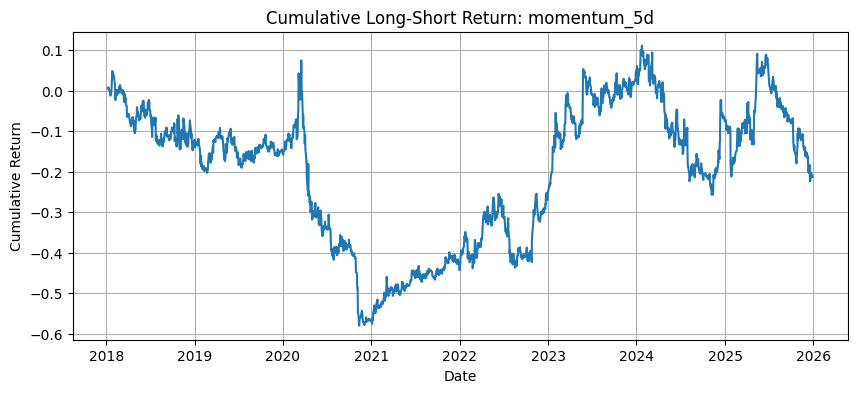

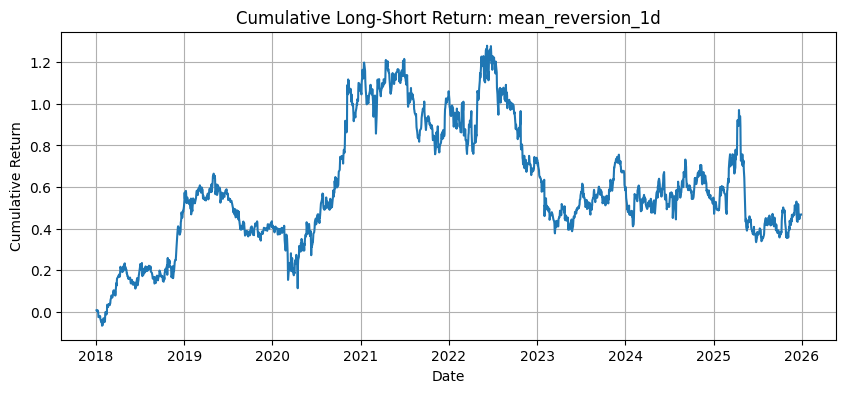

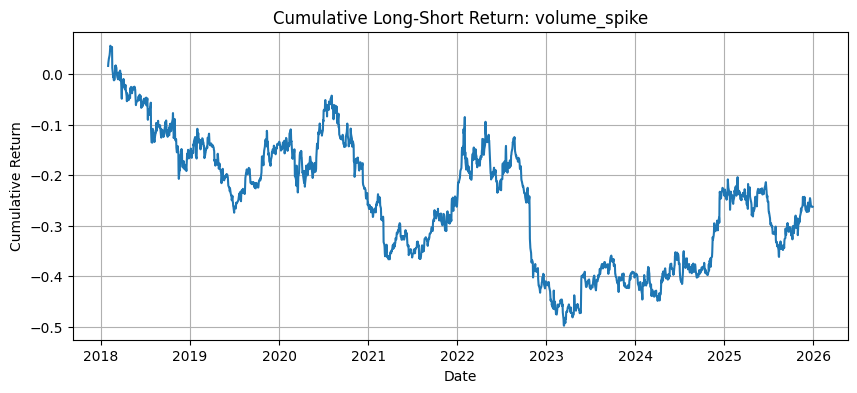

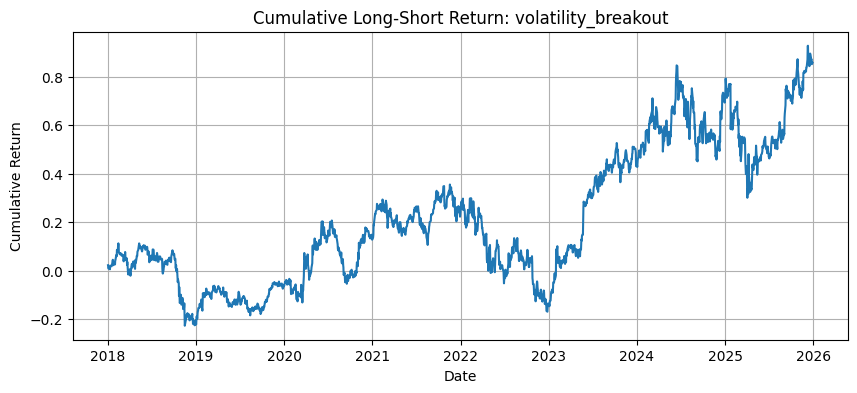

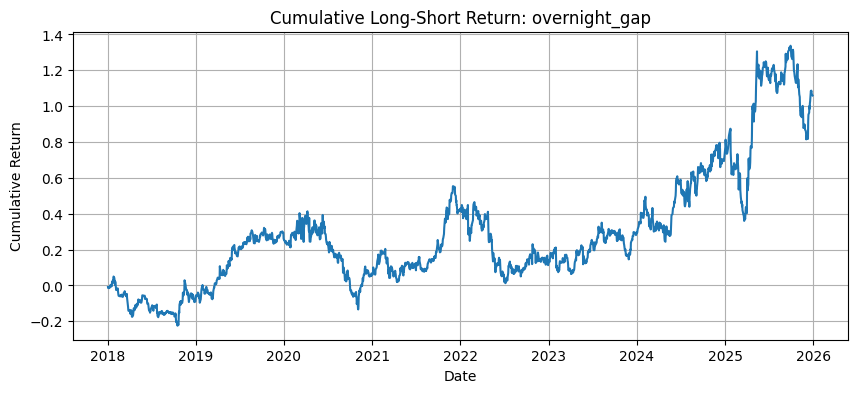

In [15]:
import matplotlib.pyplot as plt

for alpha in alpha_cols:
    temp = bt_results[bt_results["alpha"] == alpha].copy()
    temp = temp.sort_values("date")
    temp["cum_return"] = (1 + temp["long_short_return"].fillna(0)).cumprod() - 1

    plt.figure(figsize=(10, 4))
    plt.plot(temp["date"], temp["cum_return"])
    plt.title(f"Cumulative Long-Short Return: {alpha}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.show()

## Future improvements (alphas, evaluation, and backtesting)

This notebook is a strong “minimum viable” alpha research pipeline:
download data → build a panel → compute features → evaluate via IC → sanity-check via long/short returns.
Below are the most valuable next upgrades, grouped by theme.

---

### 1) Improve the alpha features (signal quality)

**A) Make signals comparable cross-sectionally**
Raw alpha values can be dominated by outliers or differences in scale across stocks.
Common improvements:
- **Winsorize / clip** extreme values (e.g., 1st/99th percentile)
- **Cross-sectional z-score** each day (normalize within date)
- **Rank-transform** (use ranks of alpha rather than raw values)

**B) Add multi-horizon variants**
Many effects are horizon-dependent. Examples:
- momentum: 5d, 20d, 60d (and skip 1–2 day “microstructure” noise)
- mean reversion: 1d vs 2–5d (short-term reversal often differs by horizon)
- volume: volume *and* dollar volume, or volume surprise scaled by volatility

**C) Volatility scaling**
Scale signals by recent volatility so position sizing is more stable:
- `signal_scaled = signal / rolling_vol`
- or build returns-based factors like `momentum / vol`

**D) Feature interactions and regimes**
Signals can work only in certain regimes:
- trend vs. choppy markets
- high vs. low volatility
- earnings/news days
Try conditional models or regime filters.

---

### 2) Improve IC evaluation (statistical hygiene)

**A) Use Rank IC more heavily**
Rank IC is robust to outliers and non-linear relationships.
Track both Pearson and Spearman, but prefer Rank IC for “factor-like” signals.

**B) Add significance diagnostics**
Beyond mean/stdev:
- **t-stat** of IC (\( \bar{IC} / (s_{IC}/\sqrt{T}) \))
- confidence intervals via bootstrap
- stability by year / regime split (2018–2020 vs 2021–2025, etc.)

**C) Neutralize common risks**
Many “alphas” are actually exposures to:
- market beta
- sector effects
- size (market cap)
Consider:
- sector-neutral ranking
- beta-neutral / residualized returns (regress out market)

---

### 3) Improve the long/short backtest (realism and robustness)

**A) Portfolio construction**
Right now, you average returns of long and short baskets equally.
Next steps:
- **Weighting schemes**: equal-weight vs. rank-weight vs. z-score-weight
- **Volatility targeting**: scale exposure so portfolio risk is stable over time
- **Dollar neutrality**: ensure long and short legs have equal gross exposure

**B) Costs and frictions (most important for realism)**
Even simple estimates help:
- transaction costs per trade (bps)
- slippage proportional to volatility / volume
- turnover tracking (how much you trade each day)
- borrow cost / short constraints (hard-to-borrow names)

**C) Timing alignment**
Be explicit about when the alpha is known vs. when you trade:
- if alpha uses close(t), you can only trade at close(t) or next open
- if alpha uses open(t), you can trade after open(t)
Match the target return window accordingly (open-to-close, close-to-close, etc.)

**D) Quantile size and universe size**
With 20 tickers and 20% tails, you have ~4 names per side.
This is noisy. Improvements:
- expand the universe (more tickers)
- test multiple quantiles (10%, 20%, 30%)
- compute “spread” between top and bottom deciles when universe is large enough

**E) Better performance reporting**
Add:
- max drawdown
- rolling Sharpe / rolling volatility
- hit rate (% positive days)
- worst/best day, tail risk (skew/kurtosis)
- per-year breakdown to see regime dependence

---

### 4) Data engineering and reproducibility

**A) Cache data locally**
Save cleaned panel data (prefer Parquet) so reruns don’t re-download.

**B) Validate inputs**
Basic checks catch subtle bugs:
- missing dates per ticker
- duplicated rows
- non-positive prices/volumes
- rolling window warm-up handling

**C) Separate “research” and “library” code**
As the project grows:
- move reusable logic into `alphaforge/` (feature builders, IC, backtester)
- keep notebooks thin and narrative-driven

---

### 5) Next research milestones

- Add more alphas (quality, value, volatility, liquidity, trend, reversal variants).
- Combine alphas into a composite (simple averaging, regression, or ML).
- Use walk-forward evaluation / train-test splits to reduce overfitting risk.
- Expand universe and add sector constraints and realistic trading assumptions.